<a href="https://colab.research.google.com/github/Adrian-estrada-chavez/clothing-sales-roi-analysis/blob/main/Clothing_sales_roi_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Definición del objetivo

Analizar el desempeño de ventas en un negocio de ropa para identificar las categorías y productos con mayor rotación y rentabilidad, con el fin de optimizar la toma de decisiones en inventario y maximizar el retorno de inversión (ROI).

#2. Exploración y Mapeo de datos en PostgreSQL (Data Discovery)

Se realizó una exploración rápida en PostgreSQL para entender la estructura general de los datos, incluyendo tablas, columnas y relaciones clave.
Esta etapa permitió comprender el modelo de datos antes de realizar un análisis más profundo en Pyhton.

##2.1.Exploración inicial

La exploración inicial se realizó utilizando consultas básicas en SQL para:

- Identificar tablas disponibles.

- Visualizar registros de ejemplo.

- Revisar estructura de los datos.

```sql
\dt para listar tablas

select * from "public"."tabla" limit 10;
para visualizar las columnas.

##2.2. Mapeo de la estructura de datos

En esta etapa inicial, utilicé SQL para auditar la base de datos y asegurar que la estructura fuera óptima para el cálculo del ROI.

###2.2.1. Núcleo de Ventas e Ingresos:

- clientes: información de los clientes.
- ventas: registros de ventas realizadas.
- detalle_venta: productos incluidos en cada venta.
- sucursales: sucursales de la empresa.

###2.2.2. Gestión de Costos e Inventario (La Inversión):

- compras: registro de compras a proveedores.

- detalle_compra: productos incluidos en cada compra.
- productos: catálogo de productos y categorias.

### 2.2.3. Logística Inversa y Ajustes (El ROI Real):

- notas_credito: devoluciones de clientes.
- detalle_ntc:  productos incluidos por devolución.
- personal: empleados de la empresa.





#3. Extracción y almacenamiento de datos

Se realizó la extracción de datos desde PostgreSQL, exportando las tablas relevantes de manera individual en formato CSV para su posterior análisis.

La exportación se llevó a cabo mediante consultas SQL utilizando el comando:


```sql
set client_encoding TO 'utf8';
\copy nombre_tabla TO 'C:/ruta/data/raw/nombre_tabla.csv' CSV HEADER;

Los archivos generados fueron almacenados en una estructura organizada de carpetas (data/raw) y posteriormente integrados en un repositorio de GitHub.

Esto permitió su carga y análisis en Python a través de Google Colab, facilitando la reproducibilidad del proyecto y la separación entre la capa de almacenamiento y la de análisis.

# 4. Carga y validación de datos

Los datos fueron almacendados en un repositorio de GitHub y posteriormente cargados en el entorno de análisis utilizando Google Colab.

Para ello se utilizaron archivos en formato CSV alojados en el repositorio, los cuales fueron importados directamente mediante Python

## 4.1 Importación de datos a colab

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
clientes_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/clientes.csv'
clientes_raw = pd.read_csv(clientes_raw_url)

In [ ]:
compras_raw_url='https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/refs/heads/main/data_raw/compras.csv'
compras_raw=pd.read_csv(compras_raw_url)

In [ ]:
dcompra_raw_url='https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/refs/heads/main/data_raw/detalle_compra.csv'
dcompra_raw=pd.read_csv(dcompra_raw_url)

In [ ]:
dntc_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/detalle_ntc.csv'
dntc_raw = pd.read_csv(dntc_raw_url)

In [ ]:
dventa_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/refs/heads/main/data_raw/detalle_venta.csv'
dventa_raw = pd.read_csv(dventa_raw_url)

In [ ]:
ntc_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/refs/heads/main/data_raw/notas_credito.csv'
ntc_raw = pd.read_csv(ntc_raw_url)

In [ ]:
personal_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/personal.csv'
personal_raw = pd.read_csv(personal_raw_url)

In [ ]:
productos_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/productos.csv'
productos_raw = pd.read_csv(productos_raw_url)

In [ ]:
sucursales_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/sucursales.csv'
sucursales_raw = pd.read_csv(sucursales_raw_url)

In [ ]:
ventas_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/refs/heads/main/data_raw/ventas.csv'
ventas_raw = pd.read_csv(ventas_raw_url)

## 4.2 Validación inicial de datos

Se realizó una validación de los datos para verificar su estructura, tipos de datos y consistencia antes del proceso de limpieza y análisis

In [ ]:
clientes_raw.head(3)

,id_cliente,nombre_cliente,ciudad,estado,codigo_postal,telefono,descuento,tipo_cliente
0,1,publico en general,xxxx,michoacan,59000,353-123-45-67,0,menudeo


In [ ]:
clientes_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_cliente      1 non-null      int64 
 1   nombre_cliente  1 non-null      object
 2   ciudad          1 non-null      object
 3   estado          1 non-null      object
 4   codigo_postal   1 non-null      int64 
 5   telefono        1 non-null      object
 6   descuento       1 non-null      int64 
 7   tipo_cliente    1 non-null      object
dtypes: int64(3), object(5)
memory usage: 196.0+ bytes


solo se localizo un cliente, publico en general.

In [ ]:
compras_raw.head(3)

,folio,fecha,marca,cantidad,subtotal,total
0,PO-000001,2024-01-04,GEEGEE,18,4018.965517,4662
1,PO-000002,2024-01-04,INA,18,4500.000000,5220
2,PO-000003,2024-01-04,HAVE,183,34269.827590,39753


In [ ]:
compras_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   folio     1007 non-null   object 
 1   fecha     1007 non-null   object 
 2   marca     1007 non-null   object 
 3   cantidad  1007 non-null   int64  
 4   subtotal  1007 non-null   float64
 5   total     1007 non-null   int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 47.3+ KB


observamos que esta tabla no tiene los sku, asi que usaremos detalle_compra.

In [ ]:
dcompra_raw.head(3)

,folio,sku,descripcion,cantidad,precio_unitario,impuesto,descuento,subtotal,importe,fecha,registro_nombre,usuario_autorizo_nombre,marca
0,PO-000001,GEE-0001,TOP DE TEJIDO DENIM BEIGE,9,228.448276,16,0,2056.034483,2385,2024-01-04,USUARIO1,ADMIN1,GEEGEE
1,PO-000001,GEE-0002,BLUSA ACANALADO CREMA,9,218.103448,16,0,1962.931034,2277,2024-01-04,USUARIO1,ADMIN1,GEEGEE
2,PO-000002,INA-0001,ENTERIZO CON LAZADA NEGRO,9,250.862069,16,0,2257.758621,2619,2024-01-04,USUARIO1,ADMIN1,INA


In [ ]:
dcompra_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7649 entries, 0 to 7648
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   folio                    7649 non-null   object 
 1   sku                      7649 non-null   object 
 2   descripcion              7649 non-null   object 
 3   cantidad                 7649 non-null   int64  
 4   precio_unitario          7649 non-null   float64
 5   impuesto                 7649 non-null   int64  
 6   descuento                7649 non-null   int64  
 7   subtotal                 7649 non-null   float64
 8   importe                  7649 non-null   int64  
 9   fecha                    7649 non-null   object 
 10  registro_nombre          7649 non-null   object 
 11  usuario_autorizo_nombre  7649 non-null   object 
 12  marca                    7649 non-null   object 
dtypes: float64(2), int64(4), object(7)
memory usage: 777.0+ KB


observamos que las columnas de fecha necesitan ser convertidas a formato datetime, el sku y marca a string

In [ ]:
dntc_raw.head(3)

,id_ntc,id_venta,id_cliente,fecha,sku,descripcion,cantidad,precio,total
0,NTC-000001,NOT-000012,1,2024-01-05,MIN-0007,PANTALON CON OLANES NEGRO,1,255,255
1,NTC-000002,NOT-000019,1,2024-01-06,MIC-0002,FALDA DE LINO TERRACOTA,1,270,270
2,NTC-000003,NOT-000020,1,2024-01-06,ACT-0001,CARDIGAN DE TEJIDO DENIM TERRACOTA,1,342,342


In [ ]:
dntc_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2060 entries, 0 to 2059
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_ntc       2060 non-null   object
 1   id_venta     2060 non-null   object
 2   id_cliente   2060 non-null   int64 
 3   fecha        2060 non-null   object
 4   sku          2060 non-null   object
 5   descripcion  2060 non-null   object
 6   cantidad     2060 non-null   int64 
 7   precio       2060 non-null   int64 
 8   total        2060 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 145.0+ KB


observamos que las columnas de fecha necesitan ser convertidas a formato datetime y sku a string.

In [ ]:
dventa_raw.head(3)

,id_venta,fecha,id_sucursal,id_cliente,sku,descripcion_producto,marca,cantidad,precio_venta_producto,descuento,iva,subtotal,total
0,NOT-000001,2024-01-05,1,1,HAV-0007,CROP TOP ACANALADO CREMA,HAVE,1,166.379310,0,16,166.379310,193
1,NOT-000002,2024-01-05,1,1,OVI-0010,BLUSA OVERSIZE ROSA PASTEL,OVI,1,274.137931,0,16,274.137931,318
2,NOT-000002,2024-01-05,1,1,SPR-0004,PANTALON AJUSTADO AZUL CIELO,SPRING HAZE,1,275.862069,0,16,275.862069,320


In [ ]:
dventa_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118200 entries, 0 to 118199
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id_venta               118200 non-null  object 
 1   fecha                  118200 non-null  object 
 2   id_sucursal            118200 non-null  int64  
 3   id_cliente             118200 non-null  int64  
 4   sku                    118200 non-null  object 
 5   descripcion_producto   118200 non-null  object 
 6   marca                  118200 non-null  object 
 7   cantidad               118200 non-null  int64  
 8   precio_venta_producto  118200 non-null  float64
 9   descuento              118200 non-null  int64  
 10  iva                    118200 non-null  int64  
 11  subtotal               118200 non-null  float64
 12  total                  118200 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 11.7+ MB


observamos que las columnas de fecha necesitan ser convertidas a formato datetime, el sku y marca a string

In [ ]:
ntc_raw.head(3)

,id_ntc,id_cliente,cantidad,precio,total
0,NTC-000001,1,1,255,255
1,NTC-000002,1,1,270,270
2,NTC-000003,1,1,342,342


In [ ]:
ntc_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2060 entries, 0 to 2059
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_ntc      2060 non-null   object
 1   id_cliente  2060 non-null   int64 
 2   cantidad    2060 non-null   int64 
 3   precio      2060 non-null   int64 
 4   total       2060 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 80.6+ KB


esta tabla no haremos nada ya que usaremos detalle_ntc.

In [ ]:
personal_raw.head(3)

,id_personal,id_sucursal,nombre_personal,departamento,puesto
0,1,1,MARIANA PEREZ,VENTAS,CAJERO
1,2,1,ISABEL MATIAS,VENTAS,CAJERO
2,3,1,PAOLA RAMIREZ,VENTAS,CAJERO


In [ ]:
personal_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_personal      12 non-null     int64 
 1   id_sucursal      12 non-null     int64 
 2   nombre_personal  12 non-null     object
 3   departamento     12 non-null     object
 4   puesto           12 non-null     object
dtypes: int64(2), object(3)
memory usage: 612.0+ bytes


No usaremos esta tabla ya que la tabla ventas ya contiene el nombre del vendedor.

In [ ]:
productos_raw.head(3)

,sku,id_producto,nombre_producto,modelo,color,talla,categoria,marca,precio_venta,costo,fecha,tipo_producto,unidad_medida,codigo_barras,Tipo_producto_afecta_inventario
0,GEE-0001,1,TOP DE TEJIDO DENIM BEIGE,NaN,NaN,NaN,TOP,GEEGEE,318,265,2024-01-04,Inventariable,Pieza,50000001,True
1,GEE-0002,2,BLUSA ACANALADO CREMA,NaN,NaN,NaN,BLUSA,GEEGEE,304,253,2024-01-04,Inventariable,Pieza,50000002,True
2,INA-0001,3,ENTERIZO CON LAZADA NEGRO,NaN,NaN,NaN,ENTERIZO,INA,350,291,2024-01-04,Inventariable,Pieza,50000003,True


In [ ]:
productos_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7649 entries, 0 to 7648
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   sku                              7649 non-null   object 
 1   id_producto                      7649 non-null   int64  
 2   nombre_producto                  7649 non-null   object 
 3   modelo                           0 non-null      float64
 4   color                            0 non-null      float64
 5   talla                            0 non-null      float64
 6   categoria                        7649 non-null   object 
 7   marca                            7649 non-null   object 
 8   precio_venta                     7649 non-null   int64  
 9   costo                            7649 non-null   int64  
 10  fecha                            7649 non-null   object 
 11  tipo_producto                    7649 non-null   object 
 12  unidad_medida       

observamos que las columnas color y talla son nulos y que las columnas sku y categoria necesitan ser convertidas a string.

In [ ]:
sucursales_raw.head(3)

,id_sucursal,encargado,ciudad,estado,telefono
0,1,LUIS MORENO,XXXXX,MICHOACAN,353-123-45-67


In [ ]:
sucursales_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_sucursal  1 non-null      int64 
 1   encargado    1 non-null      object
 2   ciudad       1 non-null      object
 3   estado       1 non-null      object
 4   telefono     1 non-null      object
dtypes: int64(1), object(4)
memory usage: 172.0+ bytes


solo hay una sucursal, asi que descartamos esta tabla.

In [ ]:
ventas_raw.head(3)

,id_venta,id_sucursal,fecha,subtotal,impuesto,total,realizo
0,NOT-000001,1,2024-01-05,166.379310,16,193,MONSERRAT INOCENCIO
1,NOT-000002,1,2024-01-05,981.034483,16,1138,GABRIEL ALFARO
2,NOT-000003,1,2024-01-05,601.724138,16,698,ISABEL MATIAS


In [ ]:
ventas_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36389 entries, 0 to 36388
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     36389 non-null  object 
 1   id_sucursal  36389 non-null  int64  
 2   fecha        36389 non-null  object 
 3   subtotal     36389 non-null  float64
 4   impuesto     36389 non-null  int64  
 5   total        36389 non-null  int64  
 6   realizo      36389 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 1.9+ MB


observamos que esta tabla no tiene los sku, asi que usaremos detalle_venta. aunque utilizaremos esta tabla para ver el ranking de los vendedores.

## 5 Limpieza de datos

Se realizó un proceso de limpieza de datos para asegurar la consistencia, integridad y calidad de la información antes del análisis.

Las acciones incluyeron la estandarización de tipos de datos, la identificación y tratamiento de valores nulos, la eliminación de duplicados y la validación de consistencia en las variables clave.

Debido a que el modelo de negocio es Retail Directo (Público General) con un punto de venta único, se eliminaran del análisis las tablas:
- clientes: solo existe publico en general.
- nota_credito: se requiere todos los detalles y la tabla dntc los tiene.
- personal: su id no esta conectado a nada y la tabla venta tiene los nombres.
- sucursal: solo existe una sucursal.
- compras: no contiene los sku y la tabla detalle_compras los tiene.

In [ ]:
dcompra=dcompra_raw.copy()
dventa=dventa_raw.copy()
ntc=dntc_raw.copy()
ventas=ventas_raw.copy()
productos=productos_raw.copy()

### 5.1 Tipo de datos

durante la validación de datos se observo los tipos de datos y se detectaron inconsistencias en texto y en fechas.
asi que aprovechando estandarizaré los datos,con mayusculas y quitando espacios innecesarios.

In [ ]:
dcompra['fecha']=pd.to_datetime(dcompra['fecha'],errors='coerce')

col_text_dcompra=dcompra.select_dtypes(include=['object']).columns
for col in col_text_dcompra:
  dcompra[col]=dcompra[col].astype('string').str.upper().str.strip()


dcompra=dcompra.rename(columns={'cantidad':'cantidad_compra','fecha':'fecha_compra'})
dcompra['costo_producto_iva']=(dcompra['precio_unitario'])*(1+(dcompra['impuesto']/100))
dcompra=dcompra[['fecha_compra','sku','marca','cantidad_compra','costo_producto_iva','importe']]
dcompra.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7649 entries, 0 to 7648
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha_compra        7649 non-null   datetime64[ns]
 1   sku                 7649 non-null   string        
 2   marca               7649 non-null   string        
 3   cantidad_compra     7649 non-null   int64         
 4   costo_producto_iva  7649 non-null   float64       
 5   importe             7649 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), string(2)
memory usage: 358.7 KB


en este caso el precio del producto no tenia iva asi que lo calculamos en una nueva columna.

In [ ]:
dventa['fecha']=pd.to_datetime(dventa['fecha'],errors='coerce')

col_text_dventa=dventa.select_dtypes(include=['object']).columns
for col in col_text_dventa:
  dventa[col]=dventa[col].astype('string').str.upper().str.strip()

dventa=dventa.rename(columns={'cantidad':'cantidad_venta','fecha':'fecha_venta'})
dventa['precio_venta_iva']=(dventa['precio_venta_producto'])*(1+(dventa['iva']/100))
dventa=dventa[['id_venta','fecha_venta','sku','marca','cantidad_venta','precio_venta_iva','total']]
dventa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118200 entries, 0 to 118199
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id_venta          118200 non-null  string        
 1   fecha_venta       118200 non-null  datetime64[ns]
 2   sku               118200 non-null  string        
 3   marca             118200 non-null  string        
 4   cantidad_venta    118200 non-null  int64         
 5   precio_venta_iva  118200 non-null  float64       
 6   total             118200 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), string(3)
memory usage: 6.3 MB


en esta caso tambien se calclulo el producto con iva

In [ ]:
ntc['fecha']=pd.to_datetime(ntc['fecha'],errors='coerce')

col_text_ntc=ntc.select_dtypes(include=['object']).columns
for col in col_text_ntc:
  ntc[col]=ntc[col].astype('string').str.upper().str.strip()

ntc=ntc.rename(columns={'fecha':'fecha_devolucion','cantidad':'cantidad_devolucion','precio':'precio_devolucion'})
ntc=ntc[['id_venta','fecha_devolucion','sku','cantidad_devolucion','precio_devolucion','total']]
ntc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2060 entries, 0 to 2059
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_venta             2060 non-null   string        
 1   fecha_devolucion     2060 non-null   datetime64[ns]
 2   sku                  2060 non-null   string        
 3   cantidad_devolucion  2060 non-null   int64         
 4   precio_devolucion    2060 non-null   int64         
 5   total                2060 non-null   int64         
dtypes: datetime64[ns](1), int64(3), string(2)
memory usage: 96.7 KB


In [ ]:
ventas['fecha']=pd.to_datetime(ventas['fecha'],errors='coerce')

col_text_ventas=ventas.select_dtypes(include=['object']).columns
for col in col_text_ventas:
  ventas[col]=ventas[col].astype('string').str.upper().str.strip()

ventas=ventas.rename(columns={'fecha':'fecha_venta','realizo':'vendedor'})
ventas=ventas[['id_venta','fecha_venta','total','vendedor']]
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36389 entries, 0 to 36388
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venta     36389 non-null  string        
 1   fecha_venta  36389 non-null  datetime64[ns]
 2   total        36389 non-null  int64         
 3   vendedor     36389 non-null  string        
dtypes: datetime64[ns](1), int64(1), string(2)
memory usage: 1.1 MB


In [ ]:
productos['fecha']=pd.to_datetime(productos['fecha'],errors='coerce')

col_text_productos=productos.select_dtypes(include=['object']).columns
for col in  col_text_productos:
  productos[col]=productos[col].astype('string').str.upper().str.strip()

productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7649 entries, 0 to 7648
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   sku                              7649 non-null   string        
 1   id_producto                      7649 non-null   int64         
 2   nombre_producto                  7649 non-null   string        
 3   modelo                           0 non-null      float64       
 4   color                            0 non-null      float64       
 5   talla                            0 non-null      float64       
 6   categoria                        7649 non-null   string        
 7   marca                            7649 non-null   string        
 8   precio_venta                     7649 non-null   int64         
 9   costo                            7649 non-null   int64         
 10  fecha                            7649 non-null   datetime64[

##5.2 Datos nulos

Se realizó la identificación de valores nulos en las diferentes tablas con el objetivo de evaluar la integridad de los datos, evitar sesgos y asegurar la calidad de los resultados obtenidos.

In [ ]:
df_seleccionados = {
  'dcompra': dcompra,
  'dventa': dventa,
  'ntc': ntc,
  'ventas':ventas,
  'productos':productos
}
for nombre, df in df_seleccionados.items():
  print(f"Valores nulos en {nombre}:")
  print(df.isna().sum())
  print('-'*40)

Valores nulos en dcompra:
fecha_compra          0
sku                   0
marca                 0
cantidad_compra       0
costo_producto_iva    0
importe               0
dtype: int64
----------------------------------------
Valores nulos en dventa:
id_venta            0
fecha_venta         0
sku                 0
marca               0
cantidad_venta      0
precio_venta_iva    0
total               0
dtype: int64
----------------------------------------
Valores nulos en ntc:
id_venta               0
fecha_devolucion       0
sku                    0
cantidad_devolucion    0
precio_devolucion      0
total                  0
dtype: int64
----------------------------------------
Valores nulos en ventas:
id_venta       0
fecha_venta    0
total          0
vendedor       0
dtype: int64
----------------------------------------
Valores nulos en productos:
sku                                   0
id_producto                           0
nombre_producto                       0
modelo                

In [ ]:
productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7649 entries, 0 to 7648
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   sku                              7649 non-null   string        
 1   id_producto                      7649 non-null   int64         
 2   nombre_producto                  7649 non-null   string        
 3   modelo                           0 non-null      float64       
 4   color                            0 non-null      float64       
 5   talla                            0 non-null      float64       
 6   categoria                        7649 non-null   string        
 7   marca                            7649 non-null   string        
 8   precio_venta                     7649 non-null   int64         
 9   costo                            7649 non-null   int64         
 10  fecha                            7649 non-null   datetime64[

Se descubrio que la tabla producto tiene 3 columnas totalmente vacias que son:
- modelo
- color
- talla

de las cuales color y talla eran importantes para tener mas exacto el analisis.

ademas de que ya se habia visuazado desde la etapa de Validación inicial de datos que estaban vacios esas columnas.

In [ ]:
productos['modelo']=productos['modelo'].fillna('SIN_MODELO')
productos['color']=productos['color'].fillna('SIN_COLOR')
productos['talla']=productos['talla'].fillna('SIN_TALLA')
productos.head(3)

,sku,id_producto,nombre_producto,modelo,color,talla,categoria,marca,precio_venta,costo,fecha,tipo_producto,unidad_medida,codigo_barras,Tipo_producto_afecta_inventario
0,GEE-0001,1,TOP DE TEJIDO DENIM BEIGE,SIN_MODELO,SIN_COLOR,SIN_TALLA,TOP,GEEGEE,318,265,2024-01-04,INVENTARIABLE,PIEZA,50000001,True
1,GEE-0002,2,BLUSA ACANALADO CREMA,SIN_MODELO,SIN_COLOR,SIN_TALLA,BLUSA,GEEGEE,304,253,2024-01-04,INVENTARIABLE,PIEZA,50000002,True
2,INA-0001,3,ENTERIZO CON LAZADA NEGRO,SIN_MODELO,SIN_COLOR,SIN_TALLA,ENTERIZO,INA,350,291,2024-01-04,INVENTARIABLE,PIEZA,50000003,True


Coloque valores a estas 3 columnas para evitar tener datos nulos y saber que paso.

In [ ]:
productos.isna().sum().sum()

np.int64(0)

## 5.2 Valores duplicados

En esta parte del proceso voy a buscar filas duplicadas en los DataFrames. Hago esto para garantizar la calidad de la información.

In [ ]:
for nombre,df in df_seleccionados.items():
  print(nombre)
  print(df.duplicated().sum())
  print('-'*40)

dcompra
0
----------------------------------------
dventa
516
----------------------------------------
ntc
0
----------------------------------------
ventas
0
----------------------------------------
productos
0
----------------------------------------


In [ ]:
duplicado=dventa[dventa.duplicated()]
duplicado

,id_venta,fecha_venta,sku,marca,cantidad_venta,precio_venta_iva,total
68,NOT-000021,2024-01-06,MIC-0008,MICHEL,1,268.0,268
69,NOT-000021,2024-01-06,MIC-0008,MICHEL,1,268.0,268
362,NOT-000118,2024-01-08,ACT-0005,ACTIVE USA,1,376.0,376
759,NOT-000236,2024-01-10,LOR-0007,LOVERICHE,1,386.0,386
968,NOT-000298,2024-01-11,MIL-0001,MILK & HONEY,1,255.0,255
...,...,...,...,...,...,...,...
117495,NOT-036174,2025-12-25,NAA-0059,NAANAA,1,278.0,278
117558,NOT-036193,2025-12-25,MIC-0323,MICHEL,1,164.0,164
117926,NOT-036302,2025-12-27,ACT-0221,ACTIVE USA,1,220.0,220
118157,NOT-036378,2025-12-28,PAP-0158,PAPERMOON,1,354.0,354


En este caso se encontraron 516 filas repetidas, sin embargo hablando con el equipo de almacén me comenta que raras veces al escanear un código repite el sku en vez de agruparlo asi que se considera que si fueron ventas legitimas. sin embargo las unificaremos mas adelante.

## 5.3 valores unico en categoria y Marca

Solo daremos un vistazo a datos unicos

In [ ]:
productos['categoria'].sort_values().unique()

<StringArray>
[   'BLUSA',   'CAMISA', 'CARDIGAN',     'CROP', 'ENTERIZO',    'FALDA',
 'PANTALON',    'SHORT',      'TOP',  'VESTIDO']
Length: 10, dtype: string

In [ ]:
productos['marca'].sort_values().unique()

<StringArray>
[                     'ACG',               'ACTIVE USA',
           'AJ LEE APPAREL',         'AMBIANCE APPAREL',
                'AVAILABLE',                    'AZURA',
                    'BAMBU',                'BETTER BE',
                   'BLASHE',                    'CAMEO',
                'CHOCOLATE',         'CI SONO CORDUROY',
                  'COLETTE',                    'CRETA',
             'DANIEL JEANS',                 'DAZZLING',
              'DOUBLE ZERO',                'DRESS DAY',
             'EDIT BY NINE',                  'ESTELLA',
                 'EVERLYNN', 'FASHION CARGO (PASSPORT)',
                   'GALITA',                   'GEEGEE',
                    'GILLI',                     'GLAM',
                     'HAVE',                    'HYFVE',
             'IF SHE LOVES',                    'IJOAH',
                 'IN 2 YOU',                      'INA',
                  'INVOICE',                     'IRIS',
                 

# 6. Análisis de Rentabilidad y Ciclo de Vida del Inventario

En esta sección se integra el costo de adquisición de mercancías con el desempeño de ventas para determinar la rentabilidad real de cada SKU. Se analizan KPIs clave y se identifican productos en fase de liquidación para optimizar el flujo de efectivo y el retorno de inversión.

## 6.1 Inversion total (costos)

Calcularemos cuanta mercancia se adquirio y cuanto se invirtio se invirtio en mercancias en un periodo de 24 meses.

- Las marcas que mas se compraron fueron: Active USA, MICHEL, LOVE TREE Y MINE.
- Las compras que se hacen cada mes varian de un anio a otro.
- Se compraron un total de 147,372 piezas.
- con compras promedio de 6140.5 piezas.
- Se inviertio un total de \$31,883,307.00.  
- con un costo promedio por mes de \$1,328,471.125.


In [ ]:
dcompra['cohorte_compra']=dcompra['fecha_compra'].dt.to_period('M')

In [ ]:
#Total de piezas compradas por marca.
compras_marca=dcompra.groupby('marca',as_index=False)['cantidad_compra'].sum()
compras_marca['%_compra']=compras_marca['cantidad_compra']/compras_marca['cantidad_compra'].sum()*100
compras_marca

,marca,cantidad_compra,%_compra
0,ACG,1605,1.089081
1,ACTIVE USA,19680,13.353961
2,AJ LEE APPAREL,876,0.594414
3,AMBIANCE APPAREL,2553,1.732351
4,AVAILABLE,2178,1.477893
...,...,...,...
72,TOSKA,1290,0.875336
73,TREND STYLES,369,0.250387
74,VERYJ,318,0.215780
75,WILL B,987,0.669734


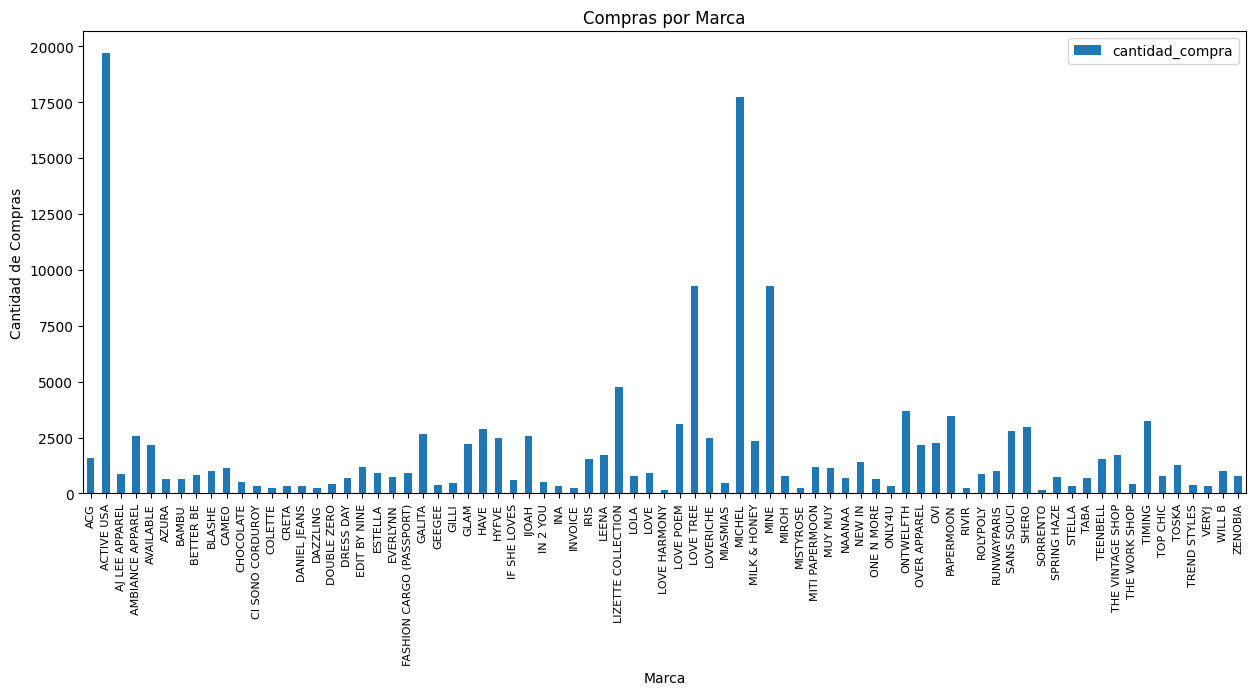

In [ ]:
#grafico de piezas por marca.
compras_marca.plot(kind='bar',x='marca',y='cantidad_compra',figsize=(15,6))
plt.title('Compras por Marca')
plt.xlabel('Marca')
plt.ylabel('Cantidad de Compras')
plt.xticks(rotation=90,fontsize=8)
plt.show()

In [ ]:
#Top 5 de marcas mas compradas.
compras_marca.sort_values(by='cantidad_compra', ascending=False).head(5)


,marca,cantidad_compra,%_compra
1,ACTIVE USA,19680,13.353961
43,MICHEL,17712,12.018565
40,LOVE TREE,9288,6.302418
45,MINE,9288,6.302418
35,LIZETTE COLLECTION,4746,3.220422


In [ ]:
#Piezas de compras por cohorte de mes.
piezas_compra_mes=dcompra.groupby('cohorte_compra',as_index=False)['cantidad_compra'].sum()
piezas_compra_mes

,cohorte_compra,cantidad_compra
0,2024-01,4719
1,2024-02,5532
2,2024-03,7500
3,2024-04,5220
4,2024-05,7569
5,2024-06,5592
6,2024-07,5157
7,2024-08,5547
8,2024-09,6279
9,2024-10,6585


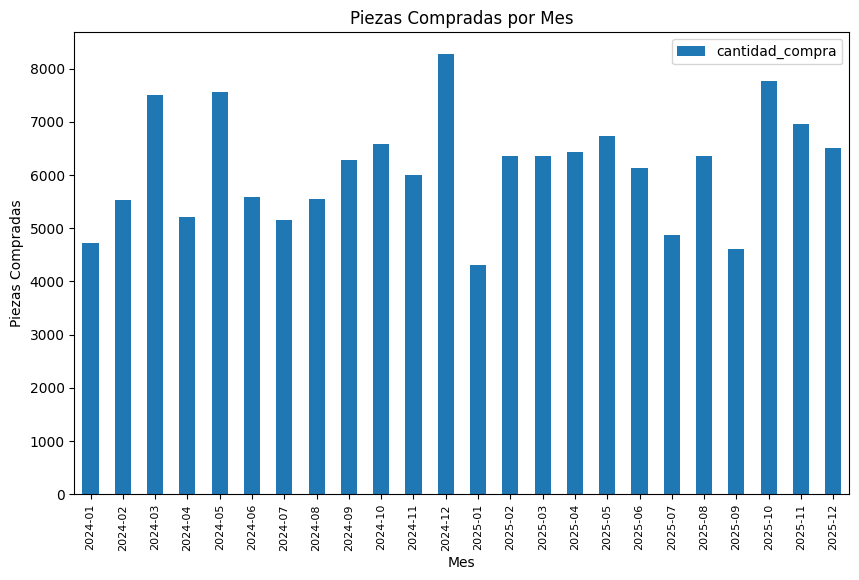

In [ ]:
#grafico de piezas compradas por mes.
piezas_compra_mes.plot(kind='bar',x='cohorte_compra',y='cantidad_compra',figsize=(10,6))
plt.title('Piezas Compradas por Mes')
plt.xlabel('Mes')
plt.ylabel('Piezas Compradas')
plt.xticks(rotation=90,fontsize=8)
plt.show()

In [ ]:
#cantidad total de piezas en 24 meses.
piezas_compra_total=piezas_compra_mes['cantidad_compra'].sum()
piezas_compra_total

np.int64(147372)

In [ ]:
#promedio de piezas compradas por mes.
piezas_promedio_mensual_compra=piezas_compra_total/24
piezas_promedio_mensual_compra

np.float64(6140.5)

-------------------------------------

In [ ]:
#compras por sku.
compras_sku=dcompra.groupby('sku',as_index=False)['cantidad_compra'].sum()
compras_sku

,sku,cantidad_compra
0,ACG-0001,9
1,ACG-0002,9
2,ACG-0003,9
3,ACG-0004,9
4,ACG-0005,9
...,...,...
7644,ZEN-0059,12
7645,ZEN-0060,15
7646,ZEN-0061,15
7647,ZEN-0062,12


In [ ]:
#costo de mercancia mensual.
costo_mercancia_mensual=dcompra.groupby('cohorte_compra',as_index=False)['importe'].sum()
costo_mercancia_mensual

,cohorte_compra,importe
0,2024-01,1075557
1,2024-02,1131339
2,2024-03,1673928
3,2024-04,1135197
4,2024-05,1590768
5,2024-06,1190694
6,2024-07,1074420
7,2024-08,1208784
8,2024-09,1408704
9,2024-10,1437234


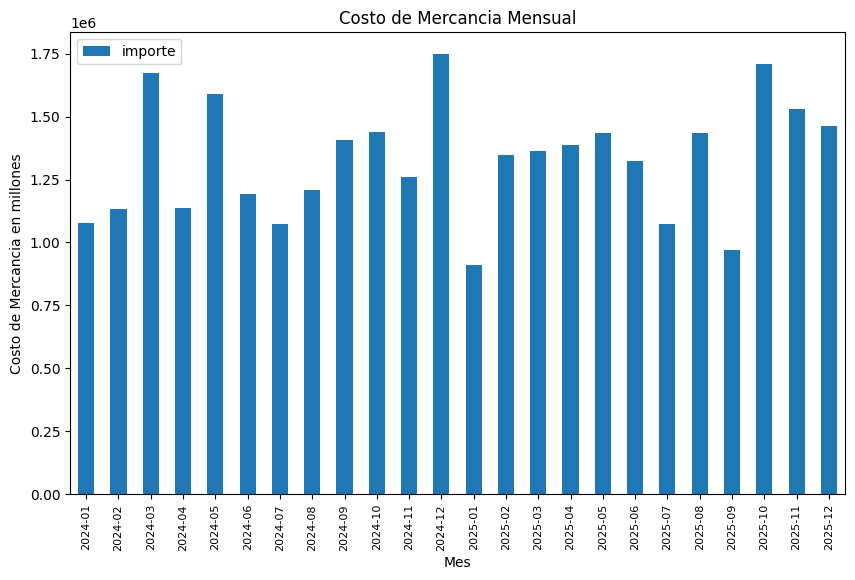

In [ ]:
#grafico de costo de mercancia mensual.
costo_mercancia_mensual.plot(kind='bar',x='cohorte_compra',y='importe',figsize=(10,6))
plt.title('Costo de Mercancia Mensual')
plt.xlabel('Mes')
plt.ylabel('Costo de Mercancia en millones')
plt.xticks(rotation=90,fontsize=8)
plt.show()

In [ ]:
#inversion total de compra en 24 meses.
costo_total=costo_mercancia_mensual['importe'].sum()
costo_total

np.int64(31883307)

In [ ]:
#costo promedio de compra mensual.
costo_promedio_mensual_compra=costo_total/24
costo_promedio_mensual_compra

np.float64(1328471.125)

-----------------------------------

Agruparemos por tiempo y marca y guardaremos para un uso futuro del dashboard.

In [ ]:
#compras por mes y marca
compras=dcompra.groupby(['cohorte_compra','marca'],as_index=False)['importe'].sum()
compras

,cohorte_compra,marca,importe
0,2024-01,ACG,18963
1,2024-01,ACTIVE USA,122019
2,2024-01,AJ LEE APPAREL,8832
3,2024-01,AZURA,10794
4,2024-01,BLASHE,8682
...,...,...,...
1002,2025-12,STELLA,2268
1003,2025-12,TEENBELL,13383
1004,2025-12,TOP CHIC,12384
1005,2025-12,VERYJ,5400


## 6.2 Analisis de ventas y liquidacion

Se generaran las agrupaciones necesarias y sumatorias para calcular las ventas, inventarios y dead stock.

### 6.2.1 Ventas generales

Calcularemos las devoluciones, ventas generales y los inventarios, ademas de generar las uniones necesarias.

#### 6.2.1.1 Devoluciones

Calcularemos las devoluciones para restarlo a las ventas y ver su impacto.

- 2,062 piezas fueron devueltas
- representa el 1.78% de las ventas
- fueron un total de: \$538,975
- hay una relacion ente el volumen de compra y la devolucion.

In [ ]:
ntc['cohorte_devolucion']=ntc['fecha_devolucion'].dt.to_period('M')

In [ ]:
# Piezas devueltas por marca y su costo
dev_marca=pd.merge(ntc,productos[['sku','marca']],on=['sku'],how='left')
dev_marca=dev_marca.groupby('marca',as_index=False).agg({'cantidad_devolucion':sum,'total':sum})
dev_marca

/tmp/ipykernel_48198/3229749640.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  dev_marca=dev_marca.groupby('marca',as_index=False).agg({'cantidad_devolucion':sum,'total':sum})


,marca,cantidad_devolucion,total
0,ACG,23,5487
1,ACTIVE USA,237,58427
2,AJ LEE APPAREL,12,2584
3,AMBIANCE APPAREL,33,6109
4,AVAILABLE,29,5556
...,...,...,...
71,TOSKA,14,4081
72,TREND STYLES,3,562
73,VERYJ,2,562
74,WILL B,11,3025


In [ ]:
dev_marca['cantidad_devolucion'].sum()

np.int64(2062)

In [ ]:
# calculo de % de devolucion por marca
dev_marca['%_devolucion']=dev_marca['cantidad_devolucion']/dev_marca['cantidad_devolucion'].sum()*100
dev_marca

,marca,cantidad_devolucion,total,%_devolucion
0,ACG,23,5487,1.115422
1,ACTIVE USA,237,58427,11.493695
2,AJ LEE APPAREL,12,2584,0.581959
3,AMBIANCE APPAREL,33,6109,1.600388
4,AVAILABLE,29,5556,1.406402
...,...,...,...,...
71,TOSKA,14,4081,0.678952
72,TREND STYLES,3,562,0.145490
73,VERYJ,2,562,0.096993
74,WILL B,11,3025,0.533463


In [ ]:
dev_marca['total'].sum()

np.int64(538975)

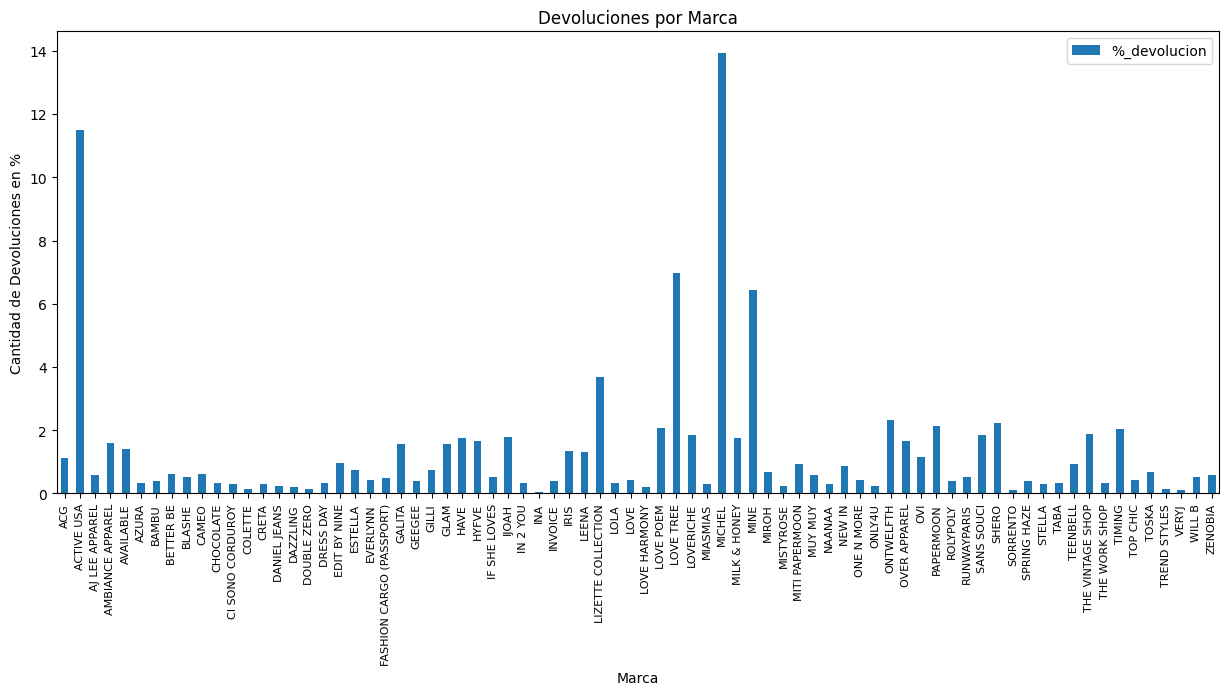

In [ ]:
#grafico de % de devolucion por marca
dev_marca.plot(kind='bar',x='marca',y='%_devolucion',figsize=(15,6))
plt.title('Devoluciones por Marca')
plt.xlabel('Marca')
plt.ylabel('Cantidad de Devoluciones en %')
plt.xticks(rotation=90,fontsize=8)
plt.show()

In [ ]:
# Top 5 de marcas con mas devoluciones
dev_marca.sort_values(by='%_devolucion', ascending=False).head(5)

,marca,cantidad_devolucion,total,%_devolucion
43,MICHEL,287,62936,13.918526
1,ACTIVE USA,237,58427,11.493695
40,LOVE TREE,144,34608,6.983511
45,MINE,133,29026,6.450048
35,LIZETTE COLLECTION,76,26117,3.685742


---------------------------

In [ ]:
#Piezas cohorte
dev_cohorte=ntc.groupby('cohorte_devolucion',as_index=False).agg({'cantidad_devolucion':sum,'total':sum})
dev_cohorte

/tmp/ipykernel_48198/708897541.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  dev_cohorte=ntc.groupby('cohorte_devolucion',as_index=False).agg({'cantidad_devolucion':sum,'total':sum})


,cohorte_devolucion,cantidad_devolucion,total
0,2024-01,40,11825
1,2024-02,72,16872
2,2024-03,77,20172
3,2024-04,72,20366
4,2024-05,83,21279
5,2024-06,71,17919
6,2024-07,63,15558
7,2024-08,72,19309
8,2024-09,86,23208
9,2024-10,89,23256


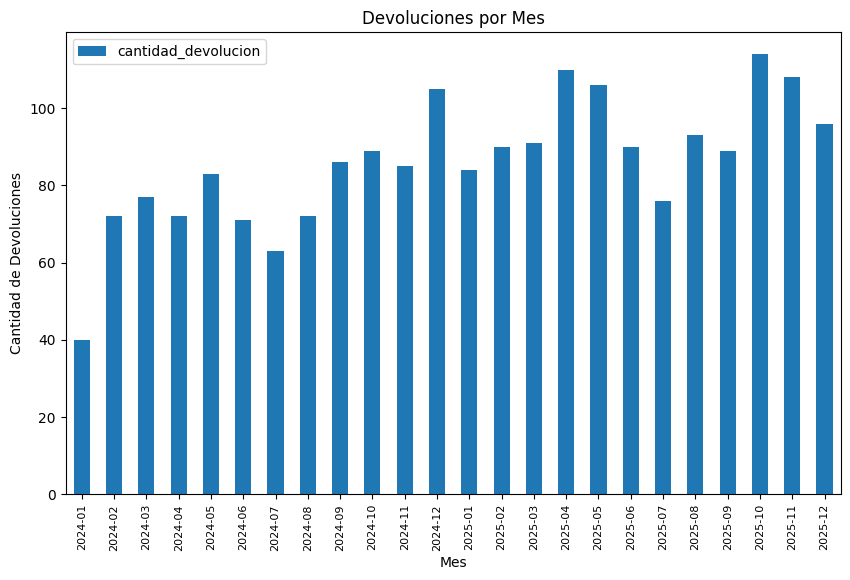

In [ ]:
dev_cohorte.plot(kind='bar',x='cohorte_devolucion',y='cantidad_devolucion',figsize=(10,6))
plt.title('Devoluciones por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Devoluciones')
plt.xticks(rotation=90,fontsize=8)
plt.show()

In [ ]:
#Meses con mas devoluciones
dev_cohorte.sort_values(by='cantidad_devolucion', ascending=False).head(5)


,cohorte_devolucion,cantidad_devolucion,total
21,2025-10,114,31425
15,2025-04,110,27785
22,2025-11,108,27935
16,2025-05,106,27621
11,2024-12,105,27234


-----------------------------------

In [ ]:
# Agrupacion por cohorte y marca
devoluciones=pd.merge(ntc,productos[['sku','marca']],on=['sku'],how='left')
devoluciones=devoluciones.groupby(['cohorte_devolucion','marca'],as_index=False)['total'].sum()
devoluciones


,cohorte_devolucion,marca,total
0,2024-01,ACTIVE USA,1195
1,2024-01,GALITA,603
2,2024-01,GEEGEE,318
3,2024-01,HAVE,310
4,2024-01,IJOAH,203
...,...,...,...
774,2025-12,PAPERMOON,1012
775,2025-12,SANS SOUCI,145
776,2025-12,SHERO,444
777,2025-12,TEENBELL,490


--------------------------------------

In [ ]:
#ver cuanto tiempo pasa desde el dia que se compro hasta el dia que lo devolvio.
tiempo_devoluciones=pd.merge(ntc,dventa[['id_venta','fecha_venta']],on='id_venta',how='left')
tiempo_devoluciones['dias_devolucion']=tiempo_devoluciones['fecha_venta']-tiempo_devoluciones['fecha_devolucion']
tiempo_devoluciones

,id_venta,fecha_devolucion,sku,cantidad_devolucion,precio_devolucion,total,cohorte_devolucion,fecha_venta,dias_devolucion
0,NOT-000012,2024-01-05,MIN-0007,1,255,255,2024-01,2024-01-05,0 days
1,NOT-000012,2024-01-05,MIN-0007,1,255,255,2024-01,2024-01-05,0 days
2,NOT-000012,2024-01-05,MIN-0007,1,255,255,2024-01,2024-01-05,0 days
3,NOT-000012,2024-01-05,MIN-0007,1,255,255,2024-01,2024-01-05,0 days
4,NOT-000012,2024-01-05,MIN-0007,1,255,255,2024-01,2024-01-05,0 days
...,...,...,...,...,...,...,...,...,...
8081,NOT-036356,2025-12-28,MIR-0069,1,163,163,2025-12,2025-12-28,0 days
8082,NOT-036356,2025-12-28,MIR-0069,1,163,163,2025-12,2025-12-28,0 days
8083,NOT-036383,2025-12-28,ACT-0228,1,237,237,2025-12,2025-12-28,0 days
8084,NOT-036383,2025-12-28,ACT-0228,1,237,237,2025-12,2025-12-28,0 days


In [ ]:
#ver si existe registros de mas de 1 dia
tiempo_devoluciones['dias_devolucion'].astype('int')
tiempo_devoluciones['dias_devolucion'].sum()

Timedelta('0 days 00:00:00')

Todas las devoluciones se hicieron el mismo dia de compra. y eso bueno, porque la politica de devoluciones es devolucion el mismo dia.

-------------------------------------

#### 6.2.2.2 Ventas Generales

Calcule las ventas generales y le restare las devoluciones para tener las ventas reales, ademas de la trazabilidad de venta por sku.

- Existe una relacion entre el volumen de compra y el ventas.
- Se vendieron un total de  116,333 piezas.
- Se vendieron un total de \$30,376,187.
-

In [ ]:
dventa['cohorte_venta']=dventa['fecha_venta'].dt.to_period('M')

vamos a restar las devoluciones de las ventas para tener el dato real.

In [ ]:
# Unificar los registros duplicados en dventa, sumando cantidad_venta y total
dventa_unificada = dventa.groupby(
    ['id_venta', 'fecha_venta', 'sku', 'marca', 'precio_venta_iva', 'cohorte_venta'],
    as_index=False).agg({'cantidad_venta':sum,'total':sum})
dventa_unificada.head()

/tmp/ipykernel_48198/1910551280.py:4: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  as_index=False).agg({'cantidad_venta':sum,'total':sum})


,id_venta,fecha_venta,sku,marca,precio_venta_iva,cohorte_venta,cantidad_venta,total
0,NOT-000001,2024-01-05,HAV-0007,HAVE,193.0,2024-01,1,193
1,NOT-000002,2024-01-05,ACT-0011,ACTIVE USA,190.0,2024-01,1,190
2,NOT-000002,2024-01-05,HAV-0005,HAVE,310.0,2024-01,1,310
3,NOT-000002,2024-01-05,OVI-0010,OVI,318.0,2024-01,1,318
4,NOT-000002,2024-01-05,SPR-0004,SPRING HAZE,320.0,2024-01,1,320


In [ ]:
#restaremos las devoluciones.
ventas_real=pd.merge(dventa_unificada,ntc[['id_venta','sku','cantidad_devolucion']],on=['id_venta','sku'],how='left')
ventas_real=ventas_real.fillna(0)
ventas_real['cantidad_venta_real']=ventas_real['cantidad_venta']-ventas_real['cantidad_devolucion']
ventas_real['total_real']=ventas_real['precio_venta_iva']*ventas_real['cantidad_venta_real']
ventas_real['cantidad_venta_real']=ventas_real['cantidad_venta_real'].astype(int)
ventas_real['total_real']=ventas_real['total_real'].astype(int)
ventas_real.head(5)

,id_venta,fecha_venta,sku,marca,precio_venta_iva,cohorte_venta,cantidad_venta,total,cantidad_devolucion,cantidad_venta_real,total_real
0,NOT-000001,2024-01-05,HAV-0007,HAVE,193.0,2024-01,1,193,0.0,1,192
1,NOT-000002,2024-01-05,ACT-0011,ACTIVE USA,190.0,2024-01,1,190,0.0,1,189
2,NOT-000002,2024-01-05,HAV-0005,HAVE,310.0,2024-01,1,310,0.0,1,309
3,NOT-000002,2024-01-05,OVI-0010,OVI,318.0,2024-01,1,318,0.0,1,317
4,NOT-000002,2024-01-05,SPR-0004,SPRING HAZE,320.0,2024-01,1,320,0.0,1,320


In [ ]:
#agrupacion de ventas por marca y dinero
ventas_marca=ventas_real.groupby('marca',as_index=False).agg({'cantidad_venta_real':sum,'total_real':sum})
ventas_marca

/tmp/ipykernel_48198/4126218695.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ventas_marca=ventas_real.groupby('marca',as_index=False).agg({'cantidad_venta_real':sum,'total_real':sum})


,marca,cantidad_venta_real,total_real
0,ACG,1343,326300
1,ACTIVE USA,15861,3764607
2,AJ LEE APPAREL,684,144067
3,AMBIANCE APPAREL,1980,355567
4,AVAILABLE,1650,317541
...,...,...,...
72,TOSKA,1009,288597
73,TREND STYLES,288,54381
74,VERYJ,263,72774
75,WILL B,735,198273


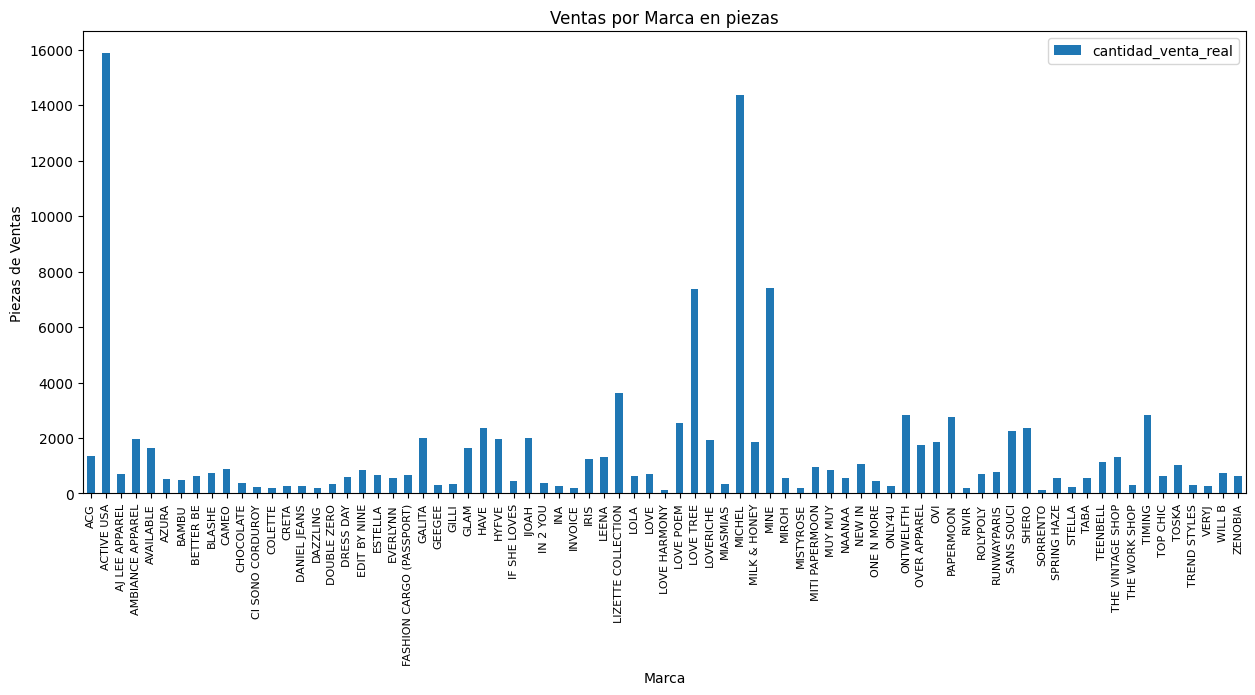

In [ ]:
#grafico de piezas por marca.
ventas_marca.plot(kind='bar',figsize=(15,6),x='marca',y='cantidad_venta_real')
plt.title('Ventas por Marca en piezas')
plt.xlabel('Marca')
plt.ylabel('Piezas de Ventas')
plt.xticks(rotation=90,fontsize=8)
plt.show()

In [ ]:
#total de piezas vendidas
ventas_real['cantidad_venta_real'].sum()

np.int64(116333)

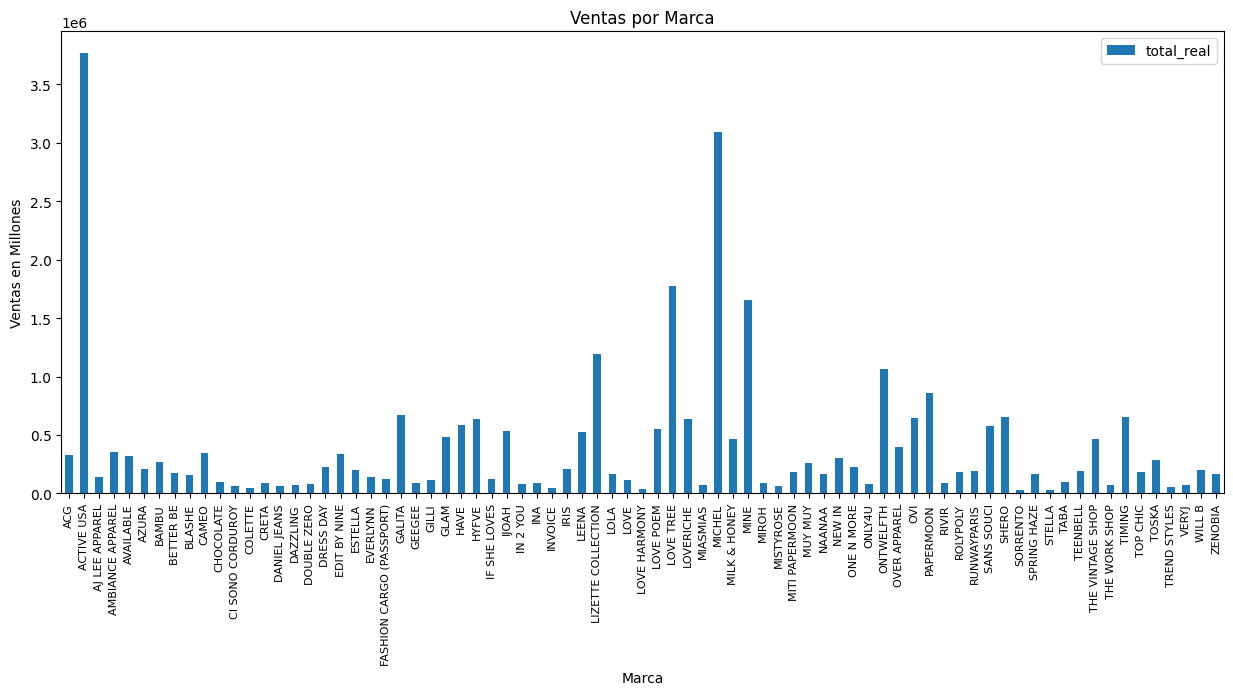

In [ ]:
#grafico de ventas por marca.
ventas_marca.plot(kind='bar',figsize=(15,6),x='marca',y='total_real')
plt.title('Ventas por Marca')
plt.xlabel('Marca')
plt.ylabel('Ventas en Millones')
plt.xticks(rotation=90,fontsize=8)
plt.show()

In [ ]:
#top 5 de marcas con mejores ventas
ventas_marca.sort_values(by='total_real', ascending=False).head(5)

,marca,cantidad_venta_real,total_real
1,ACTIVE USA,15861,3764607
43,MICHEL,14353,3096152
40,LOVE TREE,7362,1775920
45,MINE,7406,1653523
35,LIZETTE COLLECTION,3621,1196159


In [ ]:
#total de ventas.
ventas_marca['total_real'].sum()

np.int64(30320356)

--------------------------------

In [ ]:
cohorte_ventas=ventas_real.groupby('cohorte_venta',as_index=False).agg({'cantidad_venta_real':sum,'total_real':sum})
cohorte_ventas

/tmp/ipykernel_48198/325284434.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cohorte_ventas=ventas_real.groupby('cohorte_venta',as_index=False).agg({'cantidad_venta_real':sum,'total_real':sum})


,cohorte_venta,cantidad_venta_real,total_real
0,2024-01,2485,678884
1,2024-02,3204,796494
2,2024-03,4433,1189861
3,2024-04,3449,909212
4,2024-05,4940,1267836
5,2024-06,4295,1111332
6,2024-07,4000,1024786
7,2024-08,4331,1138273
8,2024-09,4950,1303007
9,2024-10,5285,1384026


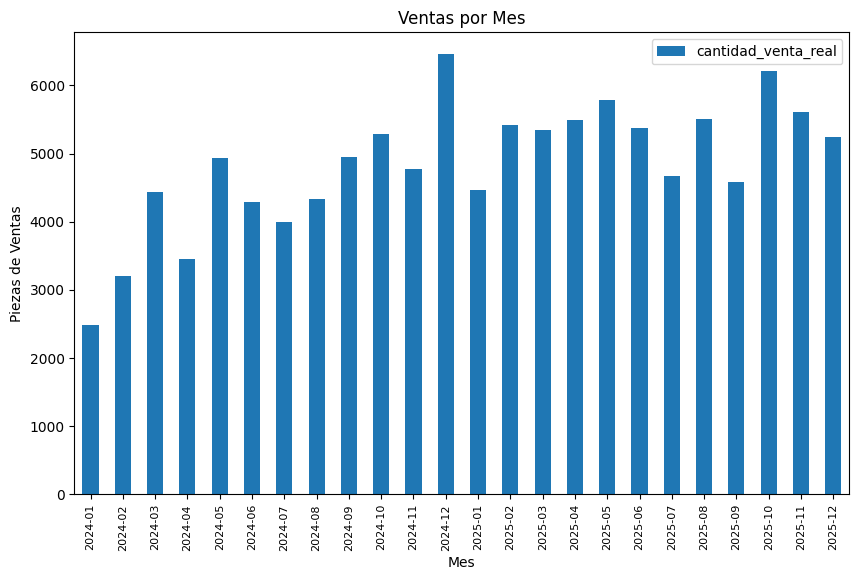

In [ ]:
# Piezas vendidas por mes
cohorte_ventas.plot(kind='bar',x='cohorte_venta',y='cantidad_venta_real',figsize=(10,6))
plt.title('Ventas por Mes')
plt.xlabel('Mes')
plt.ylabel('Piezas de Ventas')
plt.xticks(rotation=90,fontsize=8)
plt.show()

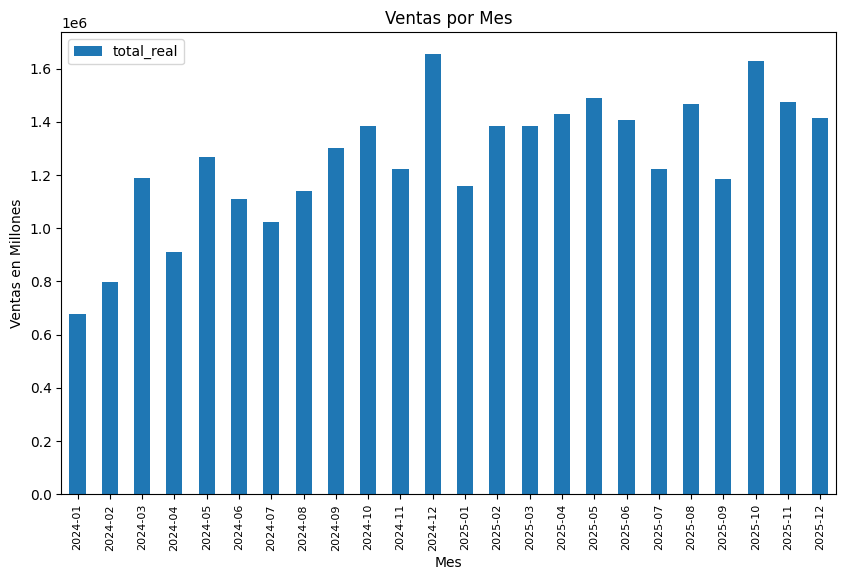

In [ ]:
# ventas por mes.
cohorte_ventas.plot(kind='bar',x='cohorte_venta',y='total_real',figsize=(10,6))
plt.title('Ventas por Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas en Millones')
plt.xticks(rotation=90,fontsize=8)
plt.show()

In [ ]:
#top 5 mejores meses
cohorte_ventas.sort_values(by='total_real', ascending=False).head(5)

,cohorte_venta,cantidad_venta_real,total_real
11,2024-12,6459,1654302
21,2025-10,6209,1626980
16,2025-05,5794,1491066
22,2025-11,5610,1473014
19,2025-08,5506,1468894


----------------------------------------

In [ ]:
# ventas por categoria
ventas_categoria=pd.merge(ventas_real,productos[['sku','categoria']],on='sku',how='left')
ventas_categoria=ventas_categoria.groupby('categoria',as_index=False).agg({'cantidad_venta_real':sum,'total_real':sum})
ventas_categoria

/tmp/ipykernel_48198/2452723393.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ventas_categoria=ventas_categoria.groupby('categoria',as_index=False).agg({'cantidad_venta_real':sum,'total_real':sum})


,categoria,cantidad_venta_real,total_real
0,BLUSA,11833,3145015
1,CAMISA,11029,2895541
2,CARDIGAN,12382,3162275
3,CROP,11836,3077950
4,ENTERIZO,11721,2986610
5,FALDA,10989,2971741
6,PANTALON,11965,3055018
7,SHORT,11322,2957163
8,TOP,11465,3005620
9,VESTIDO,11791,3063423


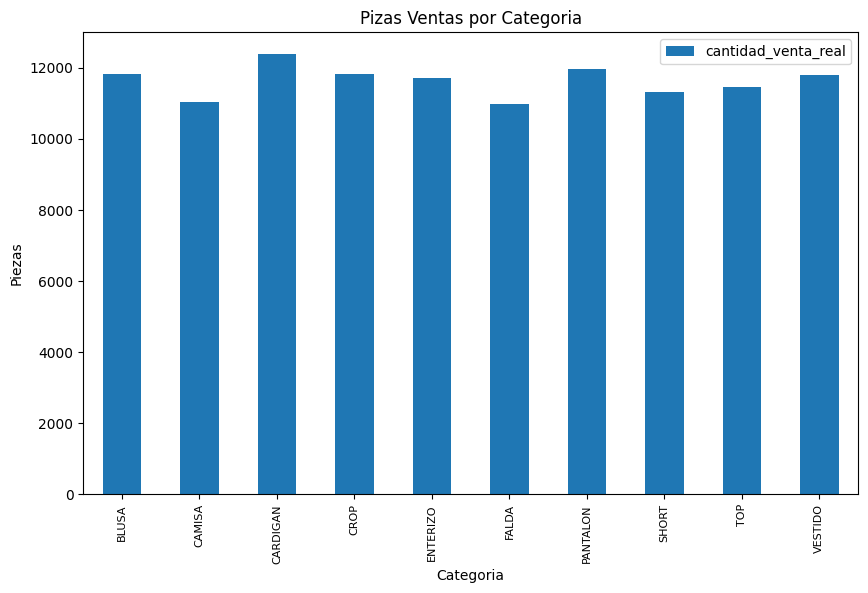

In [ ]:
# grafico de piezas por categoria.
ventas_categoria.plot(kind='bar', x='categoria',y='cantidad_venta_real',figsize=(10,6))
plt.title('Pizas Ventas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Piezas')
plt.xticks(rotation=90,fontsize=8)
plt.show()

Text(0, 0.5, 'Ventas en Millones')

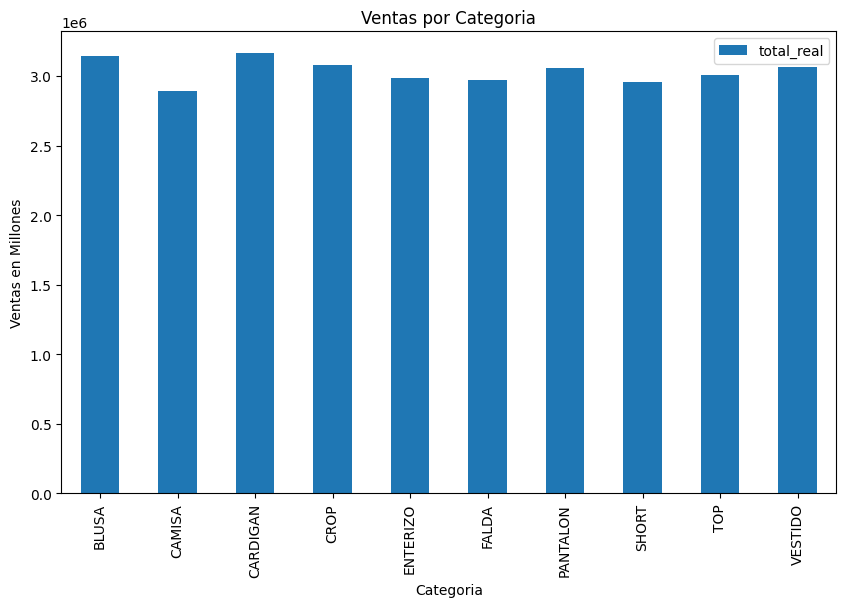

In [ ]:
# grafico por categoria en $.
ventas_categoria.plot(kind='bar', x='categoria',y='total_real',figsize=(10,6))
plt.title('Ventas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Ventas en Millones')

In [ ]:
#top 3 de mejores categorias
ventas_categoria.sort_values(by='total_real').head(3)

,categoria,cantidad_venta_real,total_real
1,CAMISA,11029,2895541
7,SHORT,11322,2957163
5,FALDA,10989,2971741


--------------------------------------

In [ ]:
#por mes y marca
venta=ventas_real.groupby(['cohorte_venta','marca'],as_index=False).agg({'cantidad_venta_real':sum,'total_real':sum})
venta


/tmp/ipykernel_48198/3417107527.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  venta=ventas_real.groupby(['cohorte_venta','marca'],as_index=False).agg({'cantidad_venta_real':sum,'total_real':sum})


,cohorte_venta,marca,cantidad_venta_real,total_real
0,2024-01,ACG,48,11790
1,2024-01,ACTIVE USA,301,76504
2,2024-01,AJ LEE APPAREL,26,5408
3,2024-01,AZURA,14,5404
4,2024-01,BLASHE,25,5270
...,...,...,...,...
1722,2025-12,TOSKA,12,3725
1723,2025-12,TREND STYLES,7,1311
1724,2025-12,VERYJ,12,3237
1725,2025-12,WILL B,46,12549


----------------------------------

### 6.2.2 Visualizacion de inventario

Uniremos y agruparemos las tablas de compras y ventas para calcular el inventario.

- existen 31,039 piezas en el inventario.
- con un costo de inventario de \$6,813,292
- existe el 21.06% de la mercancia en el almacen.
- se tienen 5 meses promedio de compra de costo de oportunidad en valor de inventario.

In [ ]:
# agrupacion de ventas para inventario
inv_venta=ventas_real.groupby('sku',as_index=False).agg({'cantidad_venta_real':sum,'total_real':sum})
inv_venta

/tmp/ipykernel_48198/2550858258.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  inv_venta=ventas_real.groupby('sku',as_index=False).agg({'cantidad_venta_real':sum,'total_real':sum})


,sku,cantidad_venta_real,total_real
0,ACG-0001,7,1876
1,ACG-0002,7,1568
2,ACG-0003,7,2037
3,ACG-0004,7,1449
4,ACG-0005,8,2144
...,...,...,...
7644,ZEN-0059,7,2037
7645,ZEN-0060,10,3350
7646,ZEN-0061,8,2216
7647,ZEN-0062,6,1524


In [ ]:
inv_compra=dcompra.groupby('sku',as_index=False).agg({'cantidad_compra':sum,'importe':sum})
inv_compra

/tmp/ipykernel_48198/2633921647.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  inv_compra=dcompra.groupby('sku',as_index=False).agg({'cantidad_compra':sum,'importe':sum})


,sku,cantidad_compra,importe
0,ACG-0001,9,2016
1,ACG-0002,9,1683
2,ACG-0003,9,2187
3,ACG-0004,9,1440
4,ACG-0005,9,2007
...,...,...,...
7644,ZEN-0059,12,2916
7645,ZEN-0060,15,4200
7646,ZEN-0061,15,3465
7647,ZEN-0062,12,2544


In [ ]:
#inventario y ganancia
inventario=pd.merge(inv_venta,inv_compra,on='sku',how='left')
inventario=pd.merge(inventario,dcompra[['sku','costo_producto_iva']],on='sku',how='left')
inventario=inventario.fillna(0)
inventario['stock']=inventario['cantidad_compra']-inventario['cantidad_venta_real']
inventario['flujo_caja']=inventario['total_real']-inventario['importe']
inventario['costo_stock']=inventario['stock']*inventario['costo_producto_iva']
inventario.head(3)

,sku,cantidad_venta_real,total_real,cantidad_compra,importe,costo_producto_iva,stock,flujo_caja,costo_stock
0,ACG-0001,7,1876,9,2016,224.0,2,-140,448.0
1,ACG-0002,7,1568,9,1683,187.0,2,-115,374.0
2,ACG-0003,7,2037,9,2187,243.0,2,-150,486.0


In [ ]:
#cantidad de piezas actual de inventario
existencias=inventario['stock'].sum()
existencias

np.int64(31039)

In [ ]:
# porcentaje de piezas en el inventario.
(existencias/dcompra['cantidad_compra'].sum())*100

np.float64(21.061667073799637)

In [ ]:
#costo de mercancias en almacen
costo_stock=inventario['costo_stock'].sum()
costo_stock

np.float64(6813292.00004819)

In [ ]:
#costo de oportunidad en meses
costo_stock/costo_promedio_mensual_compra

np.float64(5.1286715020231926)

Se tienen 5 meses de costos mensuales de compra promedio como valor actual de mercancias.

Trazabilidad de venta por sku

In [ ]:
status_stock=pd.merge(dventa,dcompra[['sku','fecha_compra']],on='sku',how='left')
status_stock['status_stock']=((status_stock['fecha_venta']-status_stock['fecha_compra'])/30).dt.days
status_stock.head(3)


,id_venta,fecha_venta,sku,marca,cantidad_venta,precio_venta_iva,total,cohorte_venta,fecha_compra,status_stock
0,NOT-000001,2024-01-05,HAV-0007,HAVE,1,193.0,193,2024-01,2024-01-04,0


In [ ]:
trazabilidad_venta=status_stock.groupby('sku')['status_stock'].mean()
trazabilidad_venta

,status_stock
sku,
ACG-0001,2.571429
ACG-0002,2.285714
ACG-0003,1.714286
ACG-0004,1.428571
ACG-0005,3.555556
...,...
ZEN-0059,0.000000
ZEN-0060,0.000000
ZEN-0061,0.000000


### 6.2.3 Dead stock y su costo.

Valoraremos la situacion del stock, su trazabilidad en el tiempo y su costo.